<a href="https://colab.research.google.com/github/RitajM1/arti560-computer-vision-labs/blob/main/lab03-image-classification-vision-transformer-vit/lab03-image-classification-vision-transformer-vit-exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 995ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 946ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


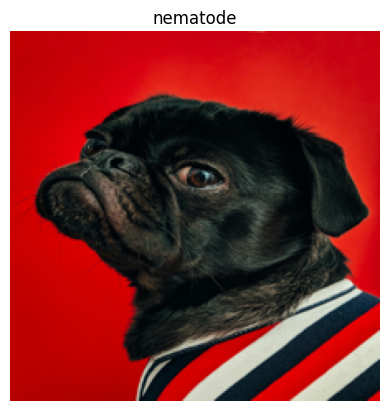

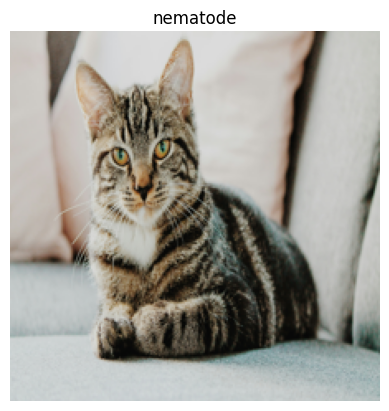

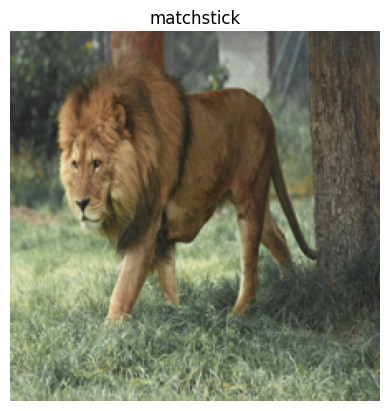

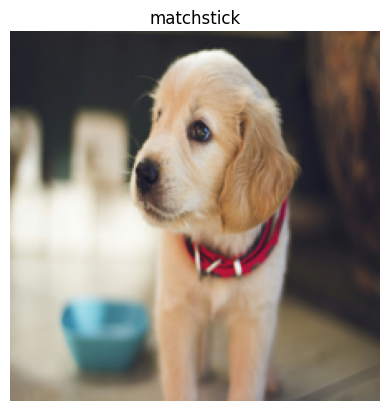

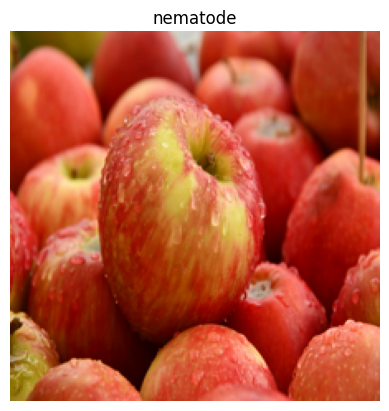

In [ ]:
# Import Libraries
import tensorflow as tf
import keras
import keras_hub
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO


# Load ViTImageClassifierPreprocessor (vit_base_patch16_224_imagenet preset)
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(
    "vit_base_patch16_224_imagenet"
)


# Load ViTImageClassifier (vit_base_patch16_224_imagenet preset)
model = keras_hub.models.ViTImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet"
)


# Load the images
urls = [
"https://images.unsplash.com/photo-1517423440428-a5a00ad493e8",
"https://images.unsplash.com/photo-1518791841217-8f162f1e1131",
"https://images.unsplash.com/photo-1546182990-dffeafbe841d",
"https://images.unsplash.com/photo-1507146426996-ef05306b995a",
"https://images.unsplash.com/photo-1567306226416-28f0efdc88ce"
]

images = []

for url in urls:
    try:
        response = requests.get(url)
        img = Image.open(BytesIO(response.content)).convert("RGB")
        img = img.resize((224,224))
        images.append(np.array(img))
    except:
        print("Failed to load:", url)


# Load ImageNet class names
labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"

response = requests.get(labels_url)
class_names = response.text.split("\n")


# Predict classes
predictions = []

for img in images:
    input_tensor = preprocessor(np.expand_dims(img, axis=0))
    preds = model.predict(input_tensor)
    predicted_class = class_names[np.argmax(preds)]
    predictions.append(predicted_class)


# Show results
for i in range(len(images)):
    plt.imshow(images[i])
    plt.axis("off")
    plt.title(predictions[i])
    plt.show()


### Record Your Results

Fill the table below based on your results:

| Image File | Predicted Label | True Label (What you searched) | Correct? (Yes/No) |
|------------|----------------|--------------------------------|-------------------|
| dog.jpg | nematode | dog | No |
| cat.jpg | nematode | cat | No |
| lion.jpg | matchstick | lion | No |
| puppy.jpg | matchstick | dog | No |
| apple.jpg | nematode | apple | No |
